# Joint Sharp Wave Ripple Detection

This tutorial walks through a compact joint SWR workflow in `neuro_py` using the session `S:\data\HMC\HMC1\day8`.

We will:

1. detect events that contain both ripple-band power and a nearby sharp-wave deflection,
2. inspect the CellExplorer-style event table,
3. load only the short LFP segment needed for plotting, and
4. visualize the raw channels and feature traces in stacked panels so the joint decision is easy to read.


In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import ndimage, signal

import neuro_py as npy
from neuro_py.detectors.sharp_wave_ripple import detect_sharp_wave_ripples

sns.set_theme(style="whitegrid", context="talk")
npy.plotting.set_plotting_defaults()


## 1) Detect joint SWRs from the session

The detector can infer channels from CellExplorer `channelTags`:

- `ripple`, `Ripple`, `CA1sp`, or `ca1sp` for the ripple channel,
- `SharpWave`, `sharpwave`, `sharp_wave`, `CA1sr`, or `ca1sr` for the sharp-wave channel, and
- `Bad` or `bad` for an optional noise channel.

The important behavior is that this is a **joint** detector. A candidate event must pass separate ripple and sharp-wave criteria, so ripple-only bursts and broad sharp-wave-only deflections are rejected.


In [ ]:
basepath = r"S:\data\HMC\HMC1\day8"

ripples = detect_sharp_wave_ripples(
    basepath=basepath,
    low_threshold=0.75,
    high_threshold=2.5,
    sharp_wave_low_threshold=0.25,
    sharp_wave_high_threshold=1.5,
    min_duration=0.020,
    max_duration=0.100,
    sharp_wave_min_duration=0.020,
    sharp_wave_max_duration=0.250,
    noise_threshold=5.0,
    merge_gap=0.010,
    boundary_mode="sharp_wave",
    save_mat=False,
)

ripples.head()


,start,stop,peaks,center,duration,amplitude,frequency,peakNormedPower,ripple_channel,noise_peakNormedPower,ripple_duration,sharp_wave_peakNormedPower,sharp_wave_amplitude,sharp_wave_duration
0,1.0104,1.1384,1.1032,1.0744,0.1280,775.503044,153.440962,6.719856,261,1.877661,0.0792,2.963279,3597.090011,0.1280
1,3.9912,4.0528,3.9984,4.0220,0.0616,458.208387,155.764570,3.583090,261,1.772558,0.0360,1.627667,1975.807248,0.0616
2,6.8256,6.8888,6.7952,6.8572,0.0632,361.647024,201.447294,2.505834,261,1.136643,0.0416,2.172490,2637.160239,0.0632
3,7.1056,7.1648,7.1368,7.1352,0.0592,1062.430029,168.280664,9.877444,261,1.361326,0.0664,5.626167,6829.537229,0.0592
4,7.1744,7.2384,7.2152,7.2064,0.0640,1207.585376,169.043238,11.183433,261,2.921434,0.0928,7.564478,9182.428640,0.0640


### Parameter guide

The defaults are intentionally conservative, but these are the parameters you will most often tune while looking at example events:

- `low_threshold`: lower z-scored ripple-envelope threshold used to set ripple candidate boundaries.
- `high_threshold`: peak z-scored ripple-envelope threshold required to accept the ripple component.
- `sharp_wave_low_threshold`: lower z-scored sharp-wave threshold used to set sharp-wave candidate boundaries.
- `sharp_wave_high_threshold`: peak z-scored sharp-wave threshold required near the ripple peak.
- `min_duration` and `max_duration`: allowed ripple-component duration in seconds.
- `sharp_wave_min_duration` and `sharp_wave_max_duration`: allowed sharp-wave-component duration in seconds.
- `noise_threshold`: optional rejection threshold on the noise-channel ripple-band feature.
- `merge_gap`: merge nearby candidate intervals separated by less than this gap in seconds.
- `boundary_mode`: use `"sharp_wave"` for sharp-wave event boundaries or `"union"` for the combined ripple/sharp-wave interval.

See `detect_sharp_wave_ripples` for the full docstring and less commonly changed options such as passbands and smoothing widths.


## 2) Inspect the joint detection output

The returned table follows the CellExplorer event convention and includes a few extra columns that are useful for QC:

- `peakNormedPower` reports the ripple feature strength,
- `sharp_wave_peakNormedPower` reports the sharp-wave feature strength, and
- `sharp_wave_duration` reports the duration of the sharp-wave component used for the final event boundary.


In [3]:
summary_columns = [
    "start",
    "stop",
    "peaks",
    "duration",
    "ripple_duration",
    "sharp_wave_duration",
    "frequency",
    "peakNormedPower",
    "sharp_wave_peakNormedPower",
    "noise_peakNormedPower",
]

print(f"Detected {len(ripples):,} joint SWR events")
display(ripples[summary_columns].head(10))


Detected 10,130 joint SWR events


,start,stop,peaks,duration,ripple_duration,sharp_wave_duration,frequency,peakNormedPower,sharp_wave_peakNormedPower,noise_peakNormedPower
0,1.0104,1.1384,1.1032,0.1280,0.0792,0.1280,153.440962,6.719856,2.963279,1.877661
1,3.9912,4.0528,3.9984,0.0616,0.0360,0.0616,155.764570,3.583090,1.627667,1.772558
2,6.8256,6.8888,6.7952,0.0632,0.0416,0.0632,201.447294,2.505834,2.172490,1.136643
3,7.1056,7.1648,7.1368,0.0592,0.0664,0.0592,168.280664,9.877444,5.626167,1.361326
4,7.1744,7.2384,7.2152,0.0640,0.0928,0.0640,169.043238,11.183433,7.564478,2.921434
5,14.0992,14.1952,14.1784,0.0960,0.0712,0.0960,179.937627,5.111370,7.625344,1.497863
6,14.6080,14.6736,14.6472,0.0656,0.0856,0.0656,171.353488,16.705884,6.487357,3.087184
7,22.3400,22.4008,22.3784,0.0608,0.0384,0.0608,170.623311,7.812916,7.285906,1.069037
8,26.8832,26.9288,26.9200,0.0456,0.0520,0.0456,172.185540,4.128629,8.845681,2.308587
9,34.6512,34.7592,34.7336,0.1080,0.0984,0.1080,172.504150,15.129065,6.308865,1.617887


## 3) Load only the LFP segment needed for plotting

The full session can be large, so the tutorial does not materialize all plotted channels. Instead, we choose a short window from the first 20 minutes and pass that interval to `LFPLoader`. Internally this lets the loader use the file memmap and read just the requested time segment.

We then rebuild two lightweight feature traces inside that window: ripple-band power from the ripple channel and a low-frequency sharp-wave difference between the ripple and sharp-wave channels.


In [ ]:
n_max_time = 20 * 60
print(
    f"Number of detected events in first {n_max_time} seconds: {(ripples.stop < n_max_time).sum()}"
)
channel_tags = npy.io.load_channel_tags(basepath)


def first_tagged_channel(tags, *keys):
    for key in keys:
        if key in tags:
            return int(np.atleast_1d(tags[key]["channels"])[0] - 1)
    return None


def zscore(values):
    values = np.asarray(values, dtype=float)
    scale = np.nanstd(values)
    if scale == 0 or np.isnan(scale):
        return np.zeros_like(values, dtype=float)
    return (values - np.nanmean(values)) / scale


ripple_channel = (
    int(ripples["ripple_channel"].iloc[0])
    if (
        not ripples.empty
        and "ripple_channel" in ripples.columns
        and not np.isnan(ripples["ripple_channel"].iloc[0])
    )
    else first_tagged_channel(channel_tags, "ripple", "Ripple", "CA1sp", "ca1sp")
)
sharp_wave_channel = first_tagged_channel(
    channel_tags, "SharpWave", "sharpwave", "sharp_wave", "CA1sr", "ca1sr"
)

if ripple_channel is None or sharp_wave_channel is None:
    raise ValueError(
        "This tutorial plot needs both ripple and sharp-wave channel tags."
    )

events_for_plot = (
    ripples.iloc[ripples.stop.values < n_max_time, :]
    .sort_values(["peakNormedPower", "sharp_wave_peakNormedPower"], ascending=False)
    .head(6)
)
plot_margin = 0.25
plot_start = max(0.0, float(events_for_plot["start"].min() - plot_margin))
plot_stop = float(events_for_plot["stop"].max() + plot_margin)
plot_epoch = np.array([[plot_start, plot_stop]])

lfp = npy.io.LFPLoader(
    basepath,
    channels=[ripple_channel, sharp_wave_channel],
    ext="lfp",
    epoch=plot_epoch,
)
fs = float(lfp.fs)
timestamps = np.asarray(lfp.abscissa_vals)
lfp_data = np.asarray(lfp.data)
raw = np.asarray(lfp_data[0]).squeeze()
sharp_wave_raw = np.asarray(lfp_data[1]).squeeze()

ripple_sos = signal.butter(4, (120.0, 250.0), btype="bandpass", fs=fs, output="sos")
ripple_filtered = signal.sosfiltfilt(ripple_sos, raw)
ripple_envelope = np.abs(signal.hilbert(ripple_filtered))
ripple_envelope = ndimage.gaussian_filter1d(
    ripple_envelope, sigma=0.004 * fs, mode="nearest"
)
ripple_power = zscore(ripple_envelope)

sharp_sos = signal.butter(4, (2.0, 50.0), btype="bandpass", fs=fs, output="sos")
ripple_low = signal.sosfiltfilt(sharp_sos, raw)
sharp_low = signal.sosfiltfilt(sharp_sos, sharp_wave_raw)
sharp_wave_diff = ripple_low - sharp_low
sharp_wave_power = zscore(sharp_wave_diff)

print(f"Ripple channel: {ripple_channel}")
print(f"Sharp-wave channel: {sharp_wave_channel}")
print(f"Loaded plotting window: {plot_start:.2f} to {plot_stop:.2f} s")
print(f"Loaded LFP shape: {lfp_data.shape}")
print(f"Sampling rate: {fs:.1f} Hz")


Number of detected events in first 1200 seconds: 426
Ripple channel: 261
Sharp-wave channel: 282
Loaded plotting window: 14.36 to 1029.30 s
Loaded LFP shape: (2, 1268676)
Sampling rate: 1250.0 Hz


## 4) Plot raw channels and feature traces

The overview stays intentionally simple: raw ripple channel and raw sharp-wave channel only, with accepted intervals shaded.

For individual examples, each event gets two stacked axes. The top axis shows the raw channels; the bottom axis shows the ripple and sharp-wave z-scored features with their high thresholds. This is easier to read than putting every trace on one set of axes, and it still shows the joint decision clearly.


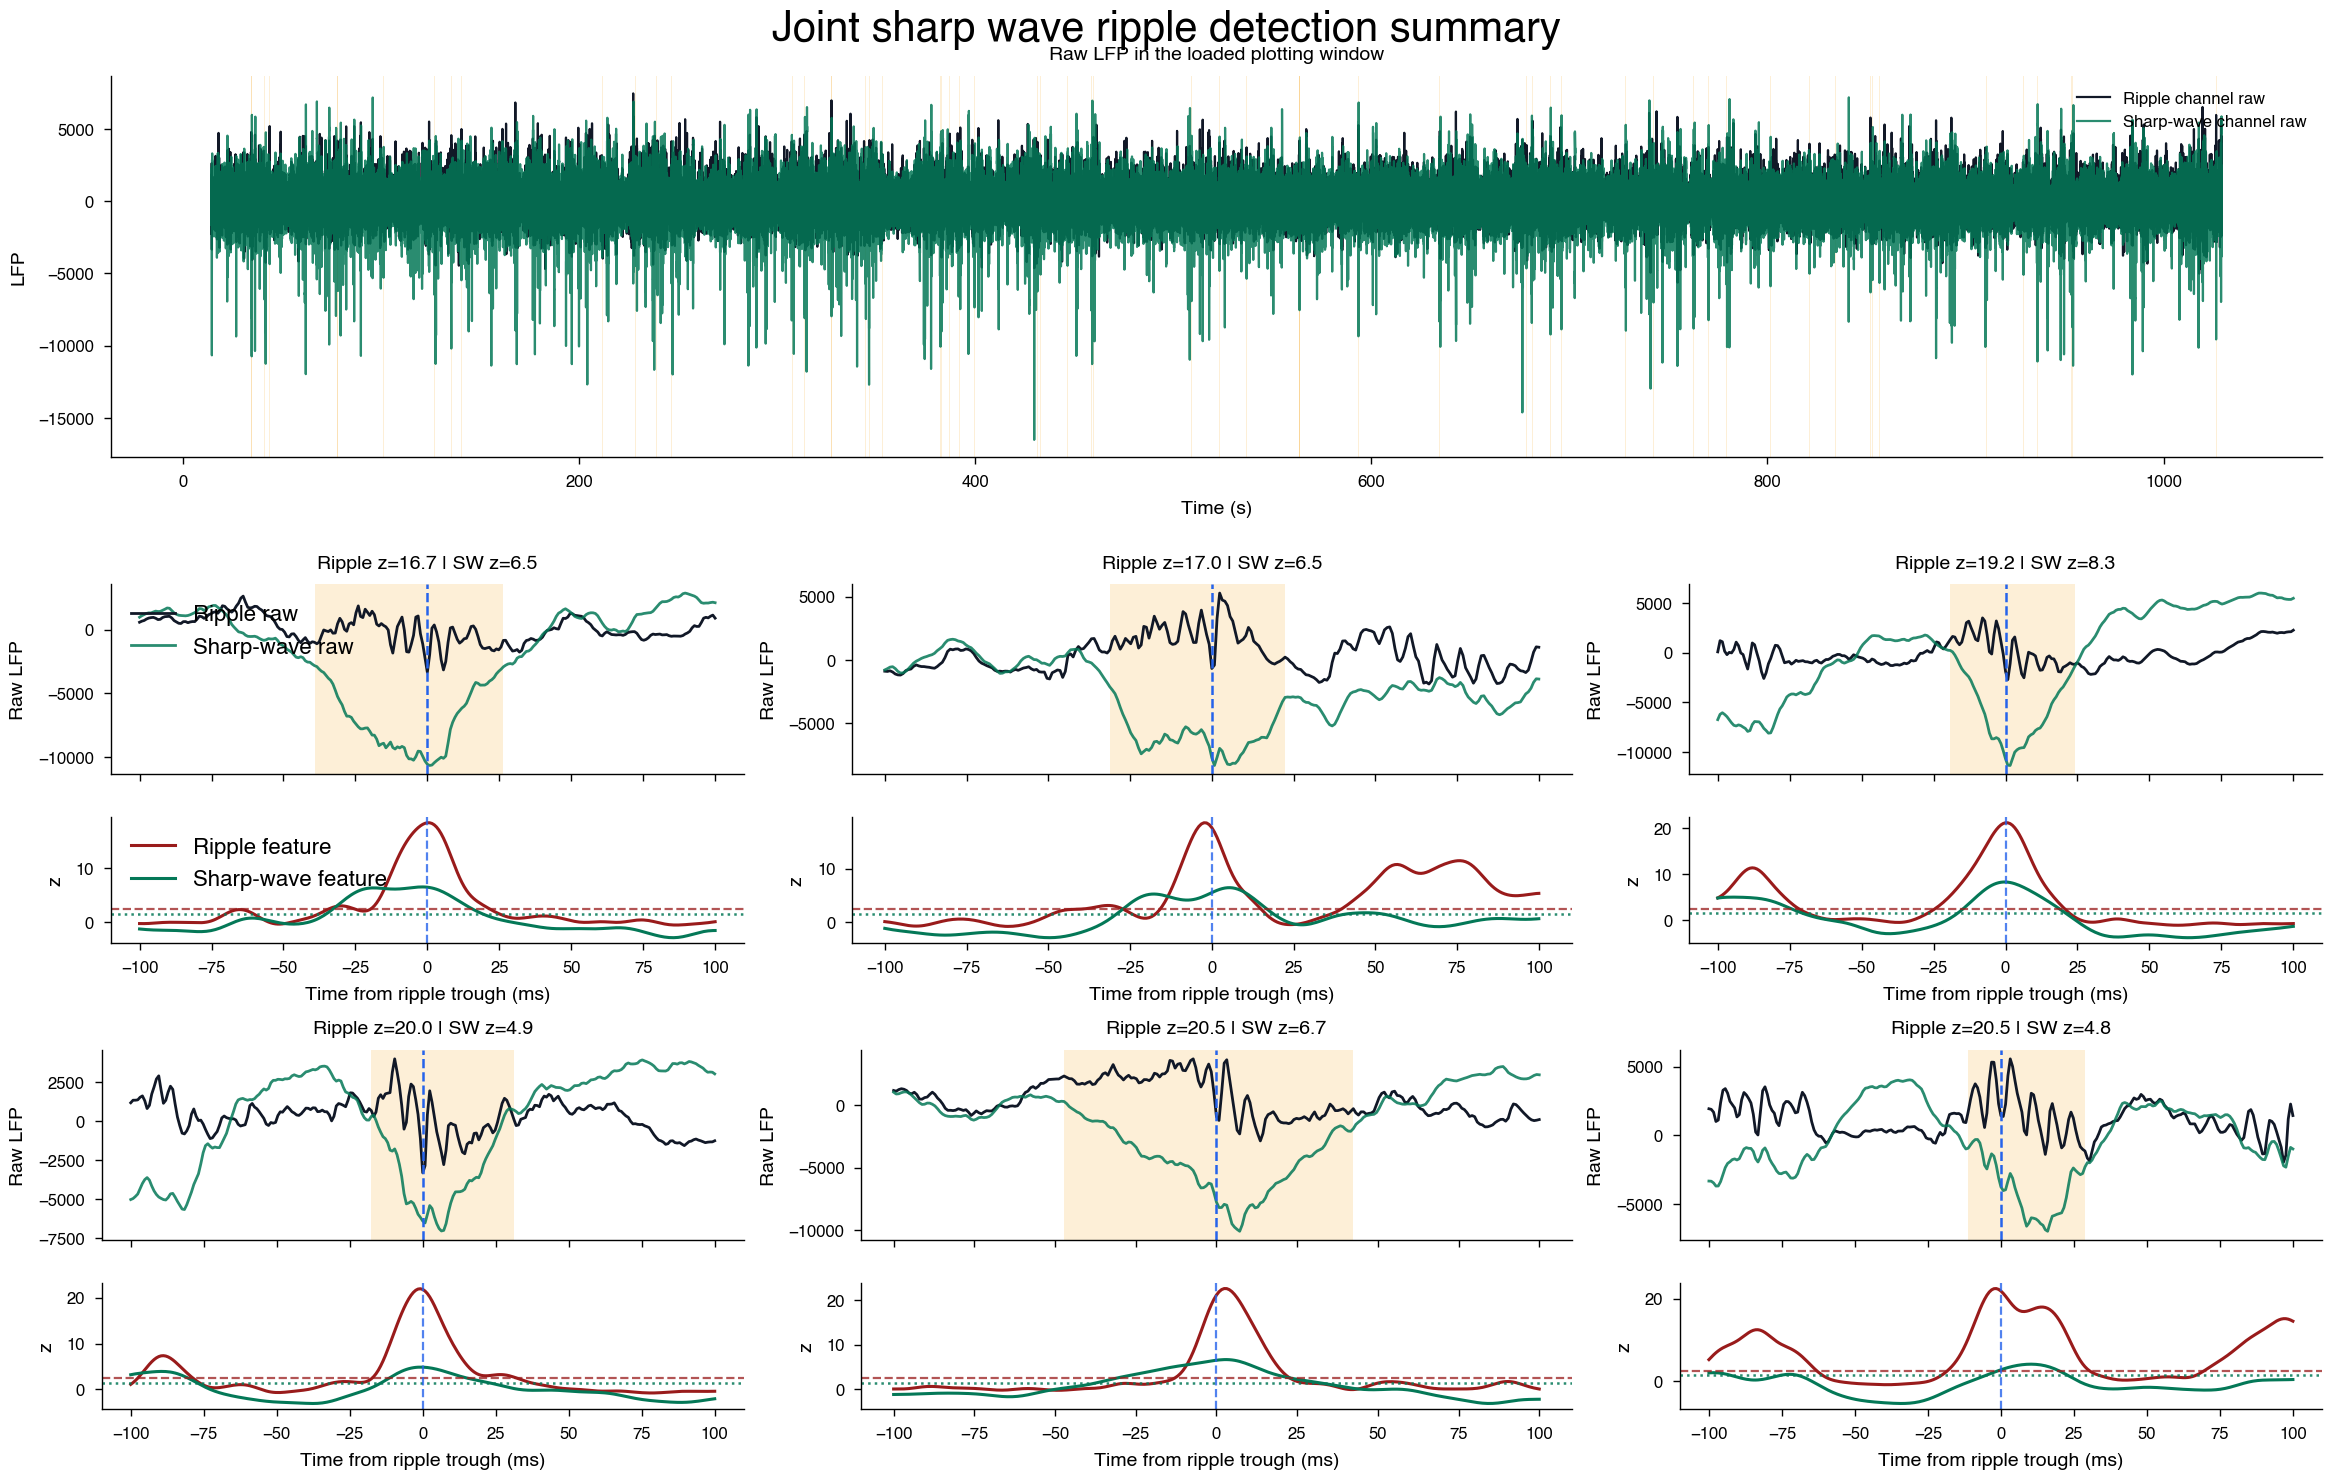

In [ ]:
def plot_joint_swr_summary(
    events,
    events_for_plot,
    timestamps,
    ripple_raw,
    sharp_wave_raw,
    ripple_power,
    sharp_wave_power,
    fs,
    ripple_high_threshold=2.5,
    sharp_wave_high_threshold=1.5,
    example_window=0.10,
):
    fig = plt.figure(
        figsize=npy.plotting.set_size("nature_double", fraction=1.65),
        constrained_layout=True,
        dpi=200,
    )
    outer = fig.add_gridspec(2, 1, height_ratios=[0.9, 2.2], hspace=0.08)

    ax_overview = fig.add_subplot(outer[0, 0])
    ax_overview.plot(
        timestamps, ripple_raw, color="#111827", lw=0.8, label="Ripple channel raw"
    )
    ax_overview.plot(
        timestamps,
        sharp_wave_raw,
        color="#047857",
        lw=0.8,
        alpha=0.85,
        label="Sharp-wave channel raw",
    )
    for start, stop in events.loc[
        (events["stop"] >= timestamps[0]) & (events["start"] <= timestamps[-1]),
        ["start", "stop"],
    ].to_numpy():
        ax_overview.axvspan(start, stop, color="#f59e0b", alpha=0.16, lw=0)
    ax_overview.set_title("Raw LFP in the loaded plotting window")
    ax_overview.set_xlabel("Time (s)")
    ax_overview.set_ylabel("LFP")
    ax_overview.legend(loc="upper right", frameon=False)

    event_grid = outer[1, 0].subgridspec(2, 3, hspace=0.34, wspace=0.22)
    event_axes = event_grid.subplots().ravel()
    half_window = int(round(example_window * fs))

    for panel_index, (container_ax, (_, event)) in enumerate(
        zip(event_axes, events_for_plot.sort_values("peaks").iterrows())
    ):
        container_ax.axis("off")
        subgrid = container_ax.get_subplotspec().subgridspec(
            2, 1, height_ratios=[1.2, 0.8], hspace=0.05
        )
        raw_ax = fig.add_subplot(subgrid[0, 0])
        feature_ax = fig.add_subplot(subgrid[1, 0], sharex=raw_ax)

        peak_idx = int(np.argmin(np.abs(timestamps - event["peaks"])))
        start_idx = max(0, peak_idx - half_window)
        stop_idx = min(len(timestamps), peak_idx + half_window + 1)
        local_time = (timestamps[start_idx:stop_idx] - event["peaks"]) * 1000.0

        raw_ax.plot(
            local_time,
            ripple_raw[start_idx:stop_idx],
            color="#111827",
            lw=1.0,
            label="Ripple raw",
        )
        raw_ax.plot(
            local_time,
            sharp_wave_raw[start_idx:stop_idx],
            color="#047857",
            lw=1.0,
            alpha=0.85,
            label="Sharp-wave raw",
        )
        raw_ax.axvspan(
            (event["start"] - event["peaks"]) * 1000.0,
            (event["stop"] - event["peaks"]) * 1000.0,
            color="#f59e0b",
            alpha=0.16,
            lw=0,
        )
        raw_ax.axvline(0.0, color="#2563eb", ls="--", lw=0.9)
        raw_ax.set_title(
            f"Ripple z={event['peakNormedPower']:.1f} | SW z={event['sharp_wave_peakNormedPower']:.1f}"
        )
        raw_ax.set_ylabel("Raw LFP")
        raw_ax.tick_params(labelbottom=False)

        feature_ax.plot(
            local_time,
            ripple_power[start_idx:stop_idx],
            color="#991b1b",
            lw=1.1,
            label="Ripple feature",
        )
        feature_ax.plot(
            local_time,
            sharp_wave_power[start_idx:stop_idx],
            color="#047857",
            lw=1.1,
            label="Sharp-wave feature",
        )
        feature_ax.axhline(
            ripple_high_threshold, color="#991b1b", ls="--", lw=0.8, alpha=0.75
        )
        feature_ax.axhline(
            sharp_wave_high_threshold, color="#047857", ls=":", lw=0.9, alpha=0.85
        )
        feature_ax.axvline(0.0, color="#2563eb", ls="--", lw=0.8, alpha=0.8)
        feature_ax.set_xlabel("Time from ripple trough (ms)")
        feature_ax.set_ylabel("z")

        if panel_index == 0:
            raw_ax.legend(loc="upper left", frameon=False, fontsize=8)
            feature_ax.legend(loc="upper left", frameon=False, fontsize=8)

    for ax in event_axes[len(events_for_plot) :]:
        ax.axis("off")

    return fig


fig = plot_joint_swr_summary(
    ripples,
    events_for_plot,
    timestamps,
    raw,
    sharp_wave_raw,
    ripple_power,
    sharp_wave_power,
    fs,
    ripple_high_threshold=2.5,
    sharp_wave_high_threshold=1.5,
)
fig.suptitle("Joint sharp wave ripple detection summary", y=1.02, fontsize=15);


## 5) Save the final joint detections to a CellExplorer event file

After the thresholds look good, rerun the detector with `save_mat=True`. Using the default `event_name="ripples"` writes a standard CellExplorer event file named `basename.ripples.events.mat`.

```python
detect_sharp_wave_ripples(
    basepath=basepath,
    low_threshold=0.75,
    high_threshold=2.5,
    sharp_wave_low_threshold=0.25,
    sharp_wave_high_threshold=1.5,
    min_duration=0.020,
    max_duration=0.100,
    sharp_wave_min_duration=0.020,
    sharp_wave_max_duration=0.250,
    noise_threshold=5.0,
    merge_gap=0.010,
    boundary_mode="sharp_wave",
    save_mat=True,
    overwrite=True,
)
```

That file can then be loaded by CellExplorer or by `neuro_py.io.loading.load_ripples_events`.
